# Spectral Graph Analysis SGA

## module 1 load and prep profile data

top

In [30]:
# %run /home/rob/argosy/sga/sga_depth_analysis.py

Start month (MM-YYYY, default 08-2023):  01-2023
End month (MM-YYYY, default 09-2024):  12-2024



Time range: 2023-01-01 to 2025-01-01
Sensors: ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'cdom', 'chlora', 'backscatter']
Data source: /home/rob/ooi/postproc/pp06

Profiles in time range:
  temperature: 3695
  salinity: 3695
  density: 3695
  dissolvedoxygen: 3695
  cdom: 2508
  chlora: 3693
  backscatter: 3690


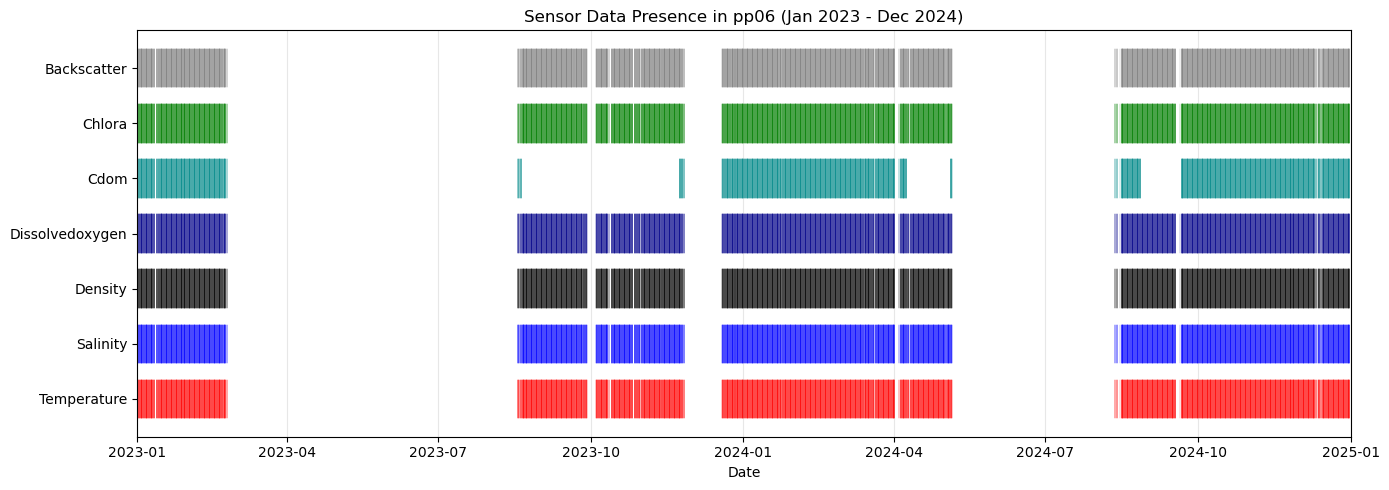


Chart saved to /home/rob/ooi/analysis/sga/sensor_presence.png


In [32]:
# %run /home/rob/argosy/sga/sga_sensor_presence.py

In [31]:
# %run /home/rob/argosy/sga/sga_config.py

=== SGA Configuration ===
  Data source: /home/rob/ooi/postproc/pp06
  Years: 2023 - 2024
  Active sensors (6): ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'chlora', 'backscatter']
  Depth grid: 27m - 185m, 80 bins
  Missing data strategy: 1
  Sigma: median
  Graph: knn (k=10)
  Laplacian: type 2
  Clustering: 10 eigvecs, k=2-10
  Final k: auto (best silhouette)

  Config saved to: /home/rob/ooi/analysis/sga/sga_config.pkl


In [33]:
%run /home/rob/argosy/sga/sga_module1.py

Module 1: Load and Index
  Data source: /home/rob/ooi/postproc/pp06
  Years: 2023 - 2024
  Active sensors (6): ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'chlora', 'backscatter']

  Total unique global indices: 3695
  Range: 15595 to 19289

  Per-sensor file counts:
    temperature: 3695
    salinity: 3695
    density: 3695
    dissolvedoxygen: 3695
    chlora: 3693
    backscatter: 3690

  Building profile index...

  Profile index: 3695 profiles
  Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

=== Module 1 Complete ===


In [34]:
%run /home/rob/argosy/sga/sga_module2.py

Module 2: Feature Matrix
  Profiles: 3695
  Sensors (6): ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'chlora', 'backscatter']
  Depth grid: 27-185m, 80 bins
  Feature matrix: (3695, 480)

  Interpolating profiles...
    temperature... 3695/3695
    salinity... 3695/3695
    density... 3695/3695
    dissolvedoxygen... 3695/3695
    chlora... 3693/3695
    backscatter... 3690/3695

=== Data Completeness ===
  temperature: 99.0%
  salinity: 98.9%
  density: 98.9%
  dissolvedoxygen: 99.0%
  chlora: 95.8%
  backscatter: 95.7%
  Overall: 97.9%
  Profiles >=50% data: 3681/3695 (99.6%)

=== Module 2 Complete ===


In [35]:
%run /home/rob/argosy/sga/sga_module3.py

Module 3: Normalize
  Feature matrix: (3695, 480)
  Missing data strategy: 1
  Removed 14 profiles with >50% missing
  Remaining: 3681
  Normalized: (3681, 480)
  Mean: 0.000000, Std: 1.000000

=== Module 3 Complete ===
  Final: 3681 profiles x 480 features


In [36]:
%run /home/rob/argosy/sga/sga_module4.py

Module 4: Similarity Graph
  Profiles: 3681
  Computing pairwise squared distances...
  Distance range: [9.14, 74435.07]
  Sigma: 25.56 (sigma^2=653.45, median_sq=653.45)
  Similarity range: [0.000000, 0.993028]
  Building 10-NN graph...
  Edges: 26161
  Creating NetworkX graph...
  Nodes: 3681, Edges: 26161
  Connected: True

=== Module 4 Complete ===


Module 5: Spectral Analysis
  Graph: 3681 nodes, 26161 edges
  Laplacian: Symmetric Normalized, shape (3681, 3681)
  Computing 50 smallest eigenvalues...

  Eigenvalue range: [-0.000000, 0.108331]
  Fiedler value (lambda_2): 0.001102
  Spectral gap (lambda_3 - lambda_2): 0.000629
  Effective dimensionality (90%): 48


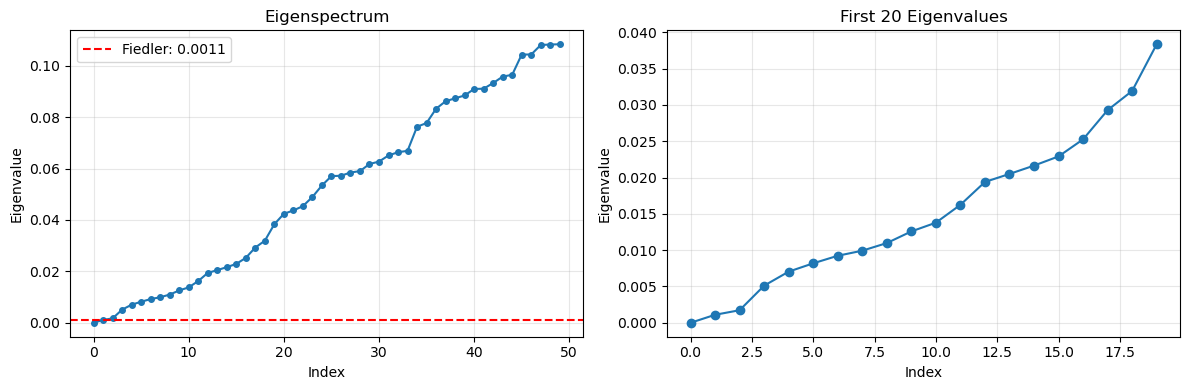

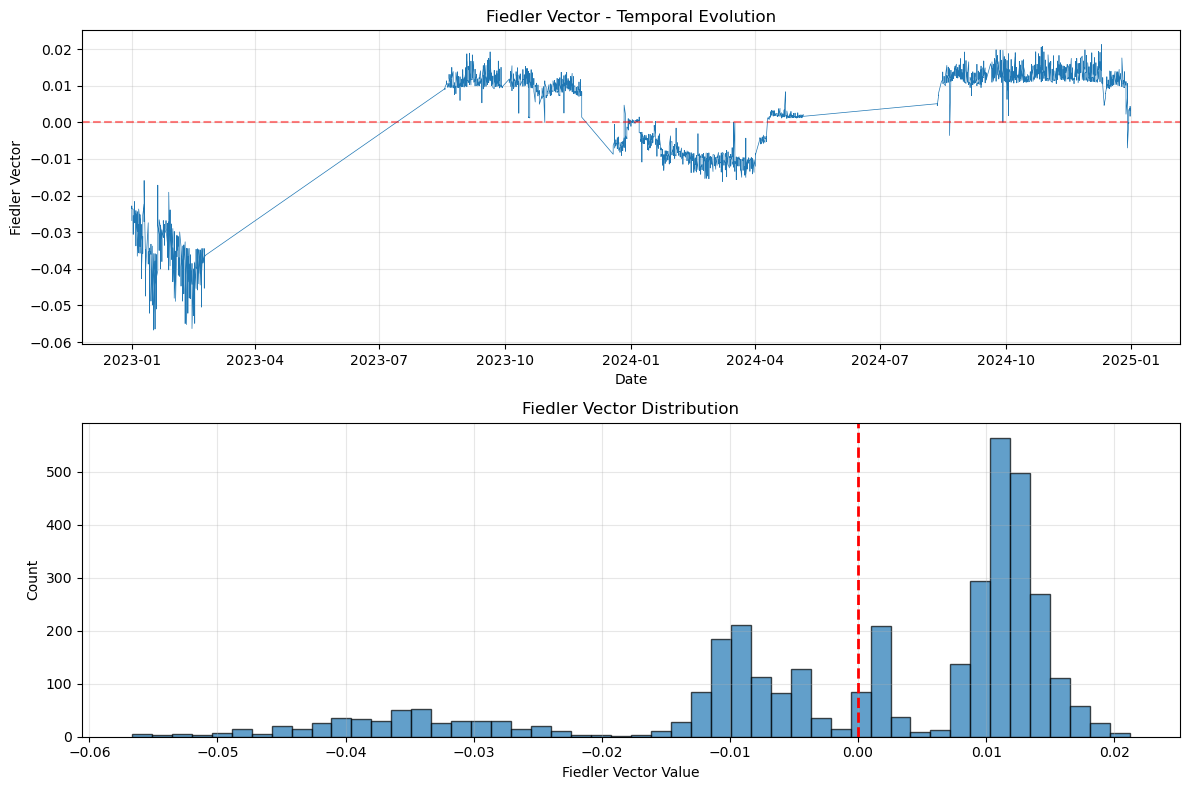


=== Module 5 Complete ===


In [37]:
%run /home/rob/argosy/sga/sga_module5.py

Module 6: Spectral Clustering
  Profiles: 3681
  Eigenvectors used: 10
  k range: 2-10

  Evaluating cluster quality...
    k=2: Silhouette=0.238, DB=0.911
    k=3: Silhouette=0.231, DB=1.743
    k=4: Silhouette=0.219, DB=1.379
    k=5: Silhouette=0.289, DB=1.226
    k=6: Silhouette=0.363, DB=1.389
    k=7: Silhouette=0.348, DB=0.830
    k=8: Silhouette=0.431, DB=0.932
    k=9: Silhouette=0.492, DB=0.781
    k=10: Silhouette=0.562, DB=0.650

  Final k (best silhouette): 10 (score=0.562)


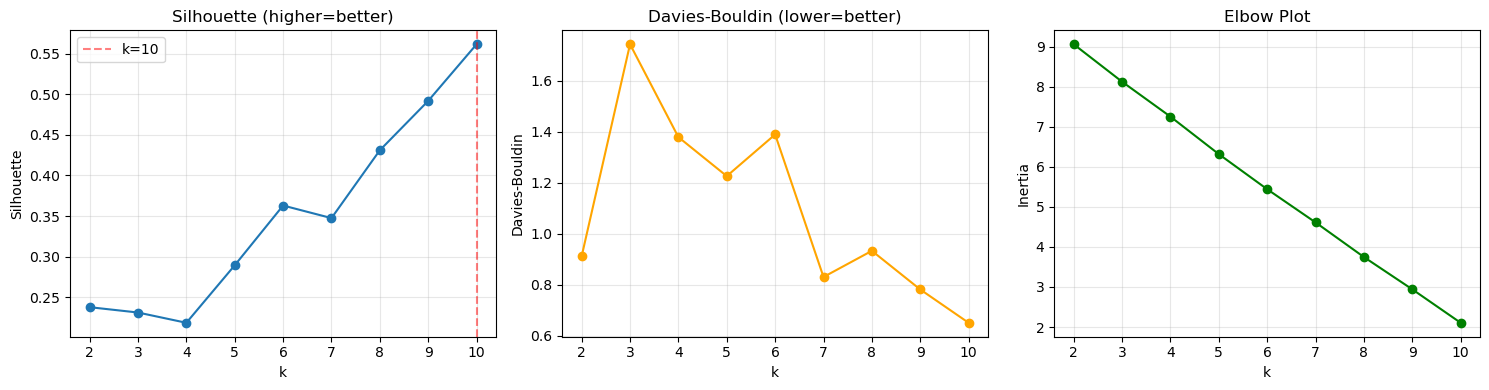


  Running final clustering with k=10...

  Cluster statistics:
    Cluster 0: 1146 profiles (31.1%), 2023-01-10 to 2024-12-29
    Cluster 1: 522 profiles (14.2%), 2023-12-19 to 2024-03-25
    Cluster 2: 518 profiles (14.1%), 2023-10-11 to 2024-08-12
    Cluster 3: 258 profiles (7.0%), 2023-01-05 to 2023-02-24
    Cluster 4: 85 profiles (2.3%), 2023-01-01 to 2023-01-13
    Cluster 5: 474 profiles (12.9%), 2024-10-15 to 2024-12-31
    Cluster 6: 214 profiles (5.8%), 2023-09-29 to 2023-11-26
    Cluster 7: 151 profiles (4.1%), 2024-02-09 to 2024-04-01
    Cluster 8: 190 profiles (5.2%), 2023-10-25 to 2024-12-13
    Cluster 9: 123 profiles (3.3%), 2023-01-21 to 2023-02-03


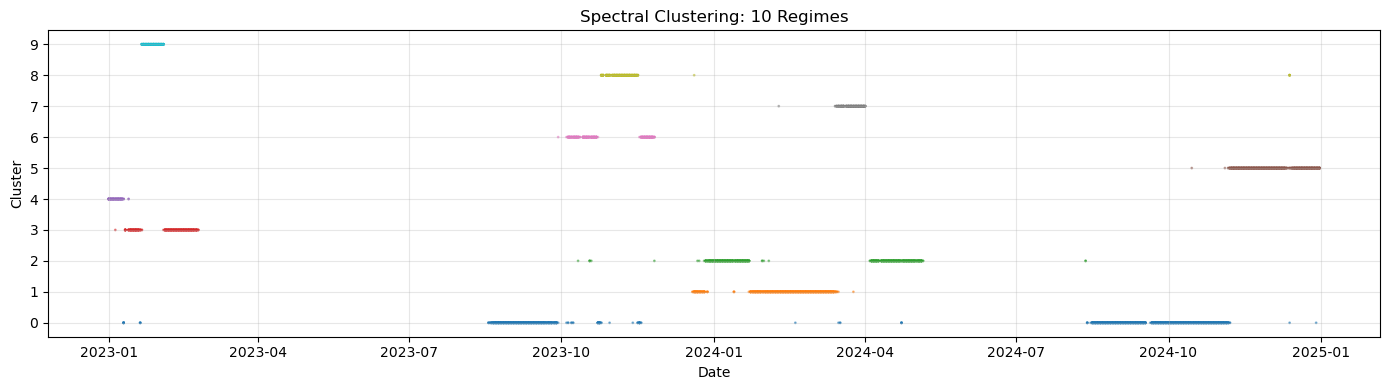


=== Module 6 Complete ===


In [38]:
%run /home/rob/argosy/sga/sga_module6.py

Loading clustering results...
Number of clusters: 10
Profiles: 3681

=== Cluster Characterization ===


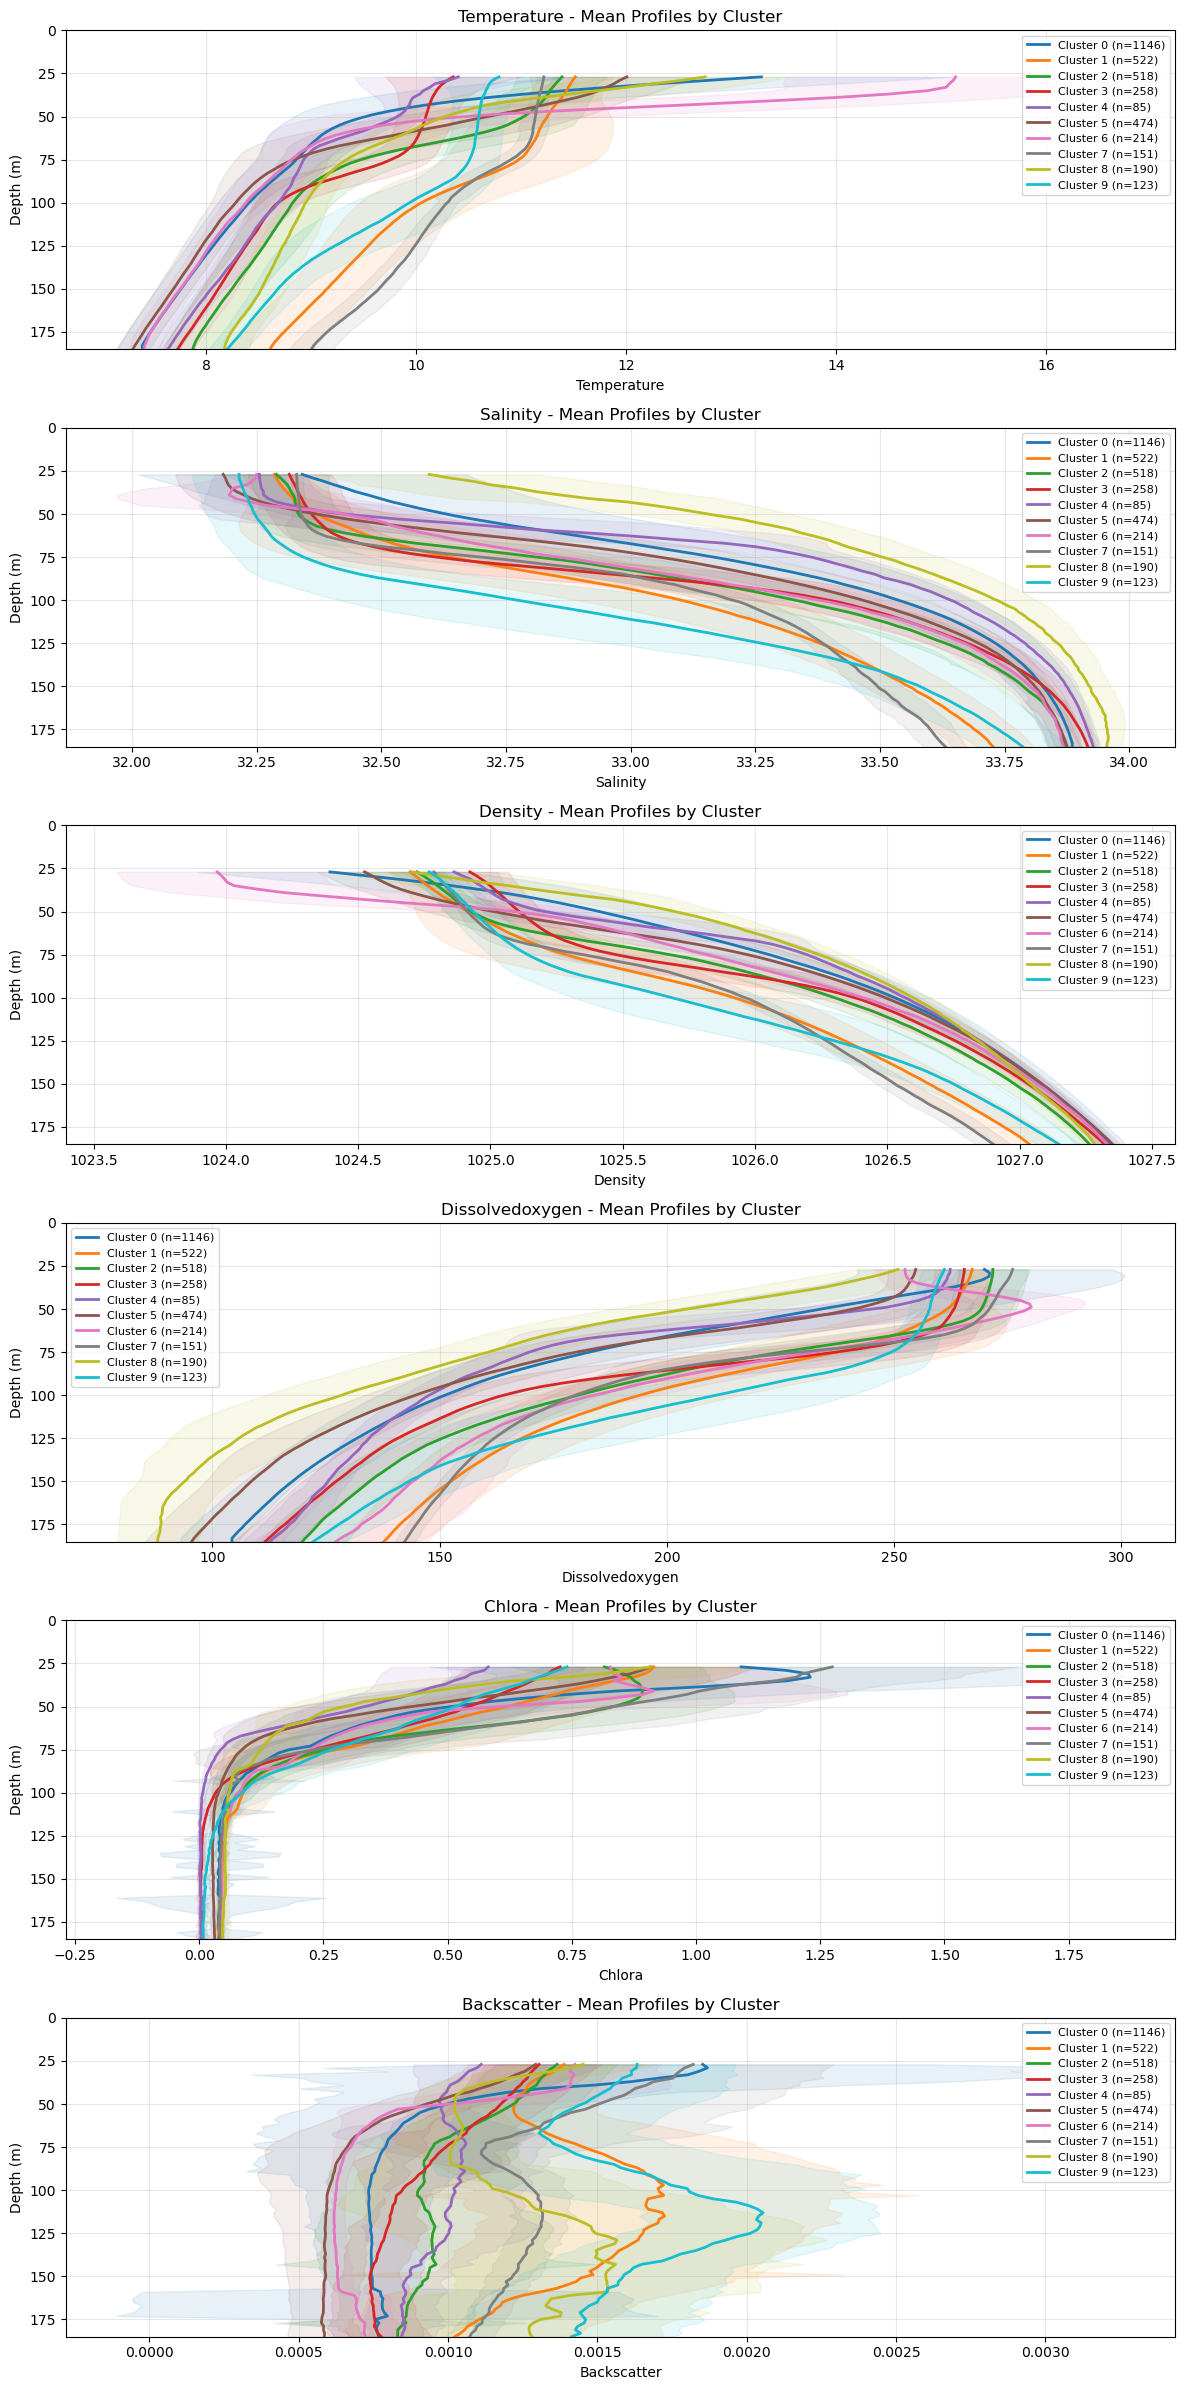

Cluster profiles plot saved.

=== Temporal Distribution ===

Cluster 0 (1146 profiles):
  Date range: 2023-01-10 00:00:00 to 2024-12-29 00:00:00
  Year distribution:
    2023: 412 profiles
    2024: 734 profiles

Cluster 1 (522 profiles):
  Date range: 2023-12-19 00:00:00 to 2024-03-25 00:00:00
  Year distribution:
    2023: 59 profiles
    2024: 463 profiles

Cluster 2 (518 profiles):
  Date range: 2023-10-11 00:00:00 to 2024-08-12 00:00:00
  Year distribution:
    2023: 50 profiles
    2024: 468 profiles

Cluster 3 (258 profiles):
  Date range: 2023-01-05 00:00:00 to 2023-02-24 00:00:00
  Year distribution:
    2023: 258 profiles

Cluster 4 (85 profiles):
  Date range: 2023-01-01 00:00:00 to 2023-01-13 00:00:00
  Year distribution:
    2023: 85 profiles

Cluster 5 (474 profiles):
  Date range: 2024-10-15 00:00:00 to 2024-12-31 00:00:00
  Year distribution:
    2024: 474 profiles

Cluster 6 (214 profiles):
  Date range: 2023-09-29 00:00:00 to 2023-11-26 00:00:00
  Year distribution:
 

In [39]:
%run /home/rob/argosy/sga/sga_module7.py